C:\Users\polor\AppData\Local\Temp\ipykernel_25312\449398568.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../data/best_model.pth', m

Analizando imágenes de validación...

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

         bkl       0.37      0.50      0.43       220
          nv       0.92      0.52      0.67      1341
          df       0.04      0.57      0.08        23
         mel       0.31      0.59      0.40       223
        vasc       0.27      0.89      0.41        28
         bcc       0.55      0.48      0.51       103
       akiec       0.32      0.12      0.18        65

    accuracy                           0.52      2003
   macro avg       0.40      0.52      0.38      2003
weighted avg       0.73      0.52      0.58      2003



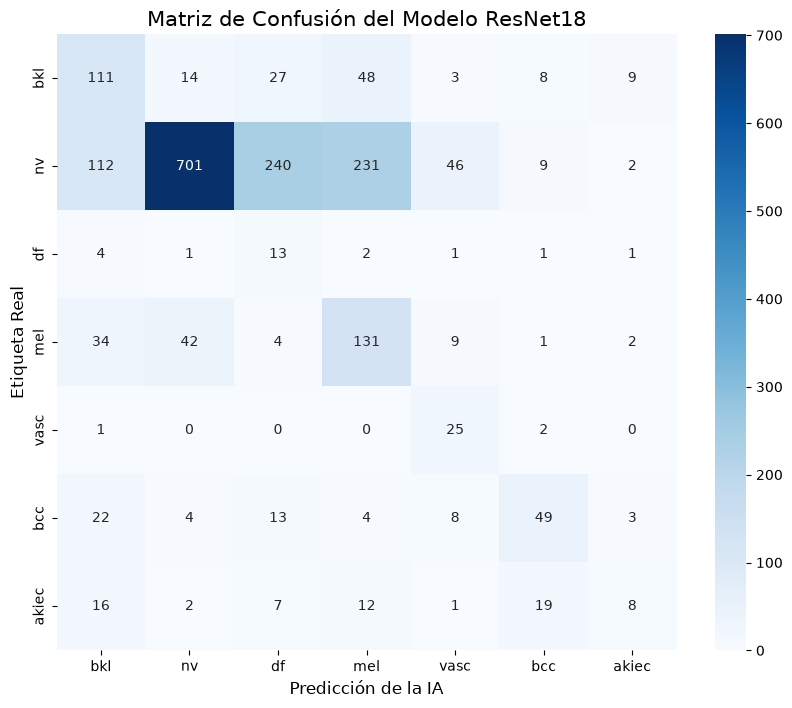

In [2]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Configuración y carga de datos
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = pd.read_csv('../data/HAM10000_metadata_prepared.csv')

clases_nombres = df['dx'].unique() # Los nombres originales (nv, mel, bcc...)
label_map = {clase: idx for idx, clase in enumerate(clases_nombres)}
df['label'] = df['dx'].map(label_map)

_, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        img = Image.open(self.dataframe.loc[idx, 'image_path']).convert('RGB')
        label = self.dataframe.loc[idx, 'label']
        if self.transform: img = self.transform(img)
        return img, label

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_loader = DataLoader(SkinCancerDataset(val_df, transform=val_transform), batch_size=32, shuffle=False)

# 2. Cargar el modelo entrenado
model = models.resnet18(weights=None) # Ya no bajamos los pesos de internet
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)
model.load_state_dict(torch.load('../data/best_model.pth', map_location=device))
model = model.to(device)
model.eval()

# 3. Hacer predicciones
all_preds = []
all_labels = []

print("Analizando imágenes de validación...")
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 4. Mostrar el reporte de métricas
print("\n--- Reporte de Clasificación ---")
print(classification_report(all_labels, all_preds, target_names=clases_nombres))

# 5. Dibujar la Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clases_nombres, yticklabels=clases_nombres)
plt.title('Matriz de Confusión del Modelo ResNet18', fontsize=15)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Predicción de la IA', fontsize=12)
plt.show()